In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Limpeza dos dados - Transformação

### Tratando Valores Faltantes

In [16]:
df_agro_boi = pd.read_csv("dados_agro.csv", parse_dates=["data"])
cols_with_nan = df_agro_boi.columns[df_agro_boi.isnull().any()].tolist()
df_agro_boi.dtypes

data                          object
Taxa_EUA                     float64
Taxa_EU                      float64
Taxa_china                   float64
boi_futuro                   float64
boi_real                     float64
boi_dolar                    float64
soja_real                    float64
soja_dolar                   float64
soja_futuro                  float64
milho_futuro                 float64
milho_real                   float64
milho_dolar                  float64
dolar                        float64
CovidPeriodFlag                int64
ciclo                         object
aspecto                       object
ano_novo_flag                  int64
carnaval_core_flag             int64
carnaval_window_flag           int64
pascoa_flag                    int64
pascoa_window_flag             int64
dias_maes_flag                 int64
dias_maes_weekend_flag         int64
festas_juninas_flag            int64
santo_antonio_flag             int64
sao_joao_flag                  int64
s

In [17]:
cols_int64 = df_agro_boi.select_dtypes(include=['int64']).columns.tolist()

In [41]:
cols_int64

['CovidPeriodFlag',
 'ano_novo_flag',
 'carnaval_core_flag',
 'carnaval_window_flag',
 'pascoa_flag',
 'pascoa_window_flag',
 'dias_maes_flag',
 'dias_maes_weekend_flag',
 'festas_juninas_flag',
 'santo_antonio_flag',
 'sao_joao_flag',
 'sao_pedro_flag',
 'ferias_midyear_flag',
 'ferias_verao_flag',
 'dias_pais_flag',
 'dias_pais_weekend_flag',
 'independencia_flag',
 'independencia_window_flag',
 'dia_criancas_flag',
 'finados_flag',
 'finados_weekend_flag',
 'natal_flag',
 'natal_window_flag',
 'fim_ano_window_flag']

In [18]:
df_agro_boi.dropna(subset=cols_int64, inplace=True)

In [19]:
cols_with_nan = df_agro_boi.columns[df_agro_boi.isnull().any()].tolist()
print(cols_with_nan)

['boi_futuro', 'boi_real', 'boi_dolar', 'soja_real', 'soja_dolar', 'soja_futuro', 'milho_futuro', 'milho_real', 'milho_dolar', 'dolar', 'precip_total_mm', 'TEMPERATURA', 'selic', 'ipca', 'pib_brasil', 'pib_agro', 'cme']


In [20]:
df_agro_boi.shape

(2209, 50)

In [21]:
df_agro_boi.columns

Index(['data', 'Taxa_EUA', 'Taxa_EU', 'Taxa_china', 'boi_futuro', 'boi_real',
       'boi_dolar', 'soja_real', 'soja_dolar', 'soja_futuro', 'milho_futuro',
       'milho_real', 'milho_dolar', 'dolar', 'CovidPeriodFlag', 'ciclo',
       'aspecto', 'ano_novo_flag', 'carnaval_core_flag',
       'carnaval_window_flag', 'pascoa_flag', 'pascoa_window_flag',
       'dias_maes_flag', 'dias_maes_weekend_flag', 'festas_juninas_flag',
       'santo_antonio_flag', 'sao_joao_flag', 'sao_pedro_flag',
       'ferias_midyear_flag', 'ferias_verao_flag', 'dias_pais_flag',
       'dias_pais_weekend_flag', 'independencia_flag',
       'independencia_window_flag', 'dia_criancas_flag', 'finados_flag',
       'finados_weekend_flag', 'natal_flag', 'natal_window_flag',
       'fim_ano_window_flag', 'sazonal_carne_weight', 'scpdsi', 'el nino',
       'precip_total_mm', 'TEMPERATURA', 'selic', 'ipca', 'pib_brasil',
       'pib_agro', 'cme'],
      dtype='object')

In [24]:
df_agro_boi.dropna(subset=['el nino', 'precip_total_mm', 'TEMPERATURA', 'ipca', 'selic', 'pib_brasil', 'pib_agro'], inplace=True)
df_agro_boi.isna().sum().sum()

np.int64(411)

In [23]:
df_agro_boi['el nino'].head()

1    INEXISTENTE
2    INEXISTENTE
5    INEXISTENTE
6    INEXISTENTE
7    INEXISTENTE
Name: el nino, dtype: object

In [25]:
cols_with_nan = df_agro_boi.columns[df_agro_boi.isnull().any()].tolist()
print(cols_with_nan)

['boi_futuro', 'boi_real', 'boi_dolar', 'soja_real', 'soja_dolar', 'soja_futuro', 'milho_futuro', 'milho_real', 'milho_dolar', 'dolar', 'cme']


In [11]:
df_agro_boi.shape

(1660, 58)

### Convertendo para Valores números valores K e M

In [26]:
# Função para converter os valores
def converter_valor(valor):
    valor = str(valor)
    valor = valor.lower().strip()
    if 'k' in valor:
        return float(valor.replace('k', '')) * 1000
    elif 'M' in valor:
        return float(valor.replace('M', '')) * 1_000_000
    elif 'm' in valor:
        return float(valor.replace('m', '')) * 1_000_000
    else:
        return float(valor)

### Tratando valores Faltantes para as séries históricas

In [29]:
df_agro_boi["data"] = pd.to_datetime(df_agro_boi["data"], dayfirst=True)
df_agro_boi.set_index("data", inplace=True)

In [42]:
cols = ['cme', 'boi_futuro', 'boi_real', 'boi_dolar', 'soja_real', 'soja_dolar', 'soja_futuro',
        'milho_futuro', 'milho_real', 'milho_dolar', 'dolar']
for col in cols:
    df_agro_boi[col] = df_agro_boi[col].ffill()

df_agro_boi.isnull().sum().sum()

np.int64(0)

In [43]:
cols_with_nan = df_agro_boi.columns[df_agro_boi.isnull().any()].tolist()

In [44]:
print(cols_with_nan)
print(df_agro_boi[cols_with_nan])

[]
Empty DataFrame
Columns: []
Index: [2020-01-02 00:00:00, 2020-01-03 00:00:00, 2020-01-06 00:00:00, 2020-01-07 00:00:00, 2020-01-08 00:00:00, 2020-01-09 00:00:00, 2020-01-10 00:00:00, 2020-01-13 00:00:00, 2020-01-14 00:00:00, 2020-01-15 00:00:00, 2020-01-16 00:00:00, 2020-01-17 00:00:00, 2020-01-20 00:00:00, 2020-01-21 00:00:00, 2020-01-22 00:00:00, 2020-01-23 00:00:00, 2020-01-24 00:00:00, 2020-01-27 00:00:00, 2020-01-28 00:00:00, 2020-01-29 00:00:00, 2020-01-30 00:00:00, 2020-01-31 00:00:00, 2020-02-03 00:00:00, 2020-02-04 00:00:00, 2020-02-05 00:00:00, 2020-02-06 00:00:00, 2020-02-07 00:00:00, 2020-02-10 00:00:00, 2020-02-11 00:00:00, 2020-02-12 00:00:00, 2020-02-13 00:00:00, 2020-02-14 00:00:00, 2020-02-17 00:00:00, 2020-02-18 00:00:00, 2020-02-19 00:00:00, 2020-02-20 00:00:00, 2020-02-21 00:00:00, 2020-02-26 00:00:00, 2020-02-27 00:00:00, 2020-02-28 00:00:00, 2020-03-02 00:00:00, 2020-03-03 00:00:00, 2020-03-04 00:00:00, 2020-03-05 00:00:00, 2020-03-06 00:00:00, 2020-03-09 00:00

In [20]:
df_agro_boi.head()

,Unnamed: 0,CovidPeriodFlag,tarifa_base_carne,tarifa_adicional_trump,tarifas_carne_total,ciclo,aspecto,Year,Month,DayOfWeek,...,boi_dolar,soja_real,soja_dolar,soja_futuro,soja_Vol.,milho_futuro,milho_Vol.,milho_real,milho_dolar,taxa
data,,,,,,,,,,,,,,,,,,,,,
2020-01-02,1,0,26.4,0.0,26.4,PICO_NASCIMENTOS,PLANEJAMENTO,2020.0,1.0,3.0,...,47.96,88.08,21.89,956.25,87370.0,391.50,103990.0,48.43,12.04,4.0260
2020-01-03,2,0,26.4,0.0,26.4,PICO_NASCIMENTOS,PLANEJAMENTO,2020.0,1.0,4.0,...,48.53,88.91,21.94,941.50,104300.0,386.50,125930.0,48.91,12.07,4.0669
2020-01-04,3,0,26.4,0.0,26.4,PICO_NASCIMENTOS,PLANEJAMENTO,2020.0,1.0,5.0,...,48.53,88.91,21.94,941.50,104300.0,386.50,125930.0,48.91,12.07,4.0669
2020-01-05,4,0,26.4,0.0,26.4,PICO_NASCIMENTOS,PLANEJAMENTO,2020.0,1.0,6.0,...,48.53,88.91,21.94,941.50,104300.0,386.50,125930.0,48.91,12.07,4.0669
2020-01-06,5,0,26.4,0.0,26.4,PICO_NASCIMENTOS,PLANEJAMENTO,2020.0,1.0,0.0,...,48.24,88.24,21.68,944.75,86230.0,384.75,112130.0,48.99,12.03,4.0616


### Variáveis Categóricas

In [35]:
obj_cols = df_agro_boi.select_dtypes(include=['object'])

In [38]:
obj_cols_names = obj_cols.columns
print(obj_cols_names)

Index(['ciclo', 'aspecto', 'el nino'], dtype='object')


In [39]:
df_agro_boi.isnull().sum().sum()

np.int64(0)

In [40]:
df_agro_boi['ciclo']

data
2020-01-02    PICO_NASCIMENTOS
2020-01-03    PICO_NASCIMENTOS
2020-01-06    PICO_NASCIMENTOS
2020-01-07    PICO_NASCIMENTOS
2020-01-08    PICO_NASCIMENTOS
                    ...       
2025-11-24       ESTACAO_MONTA
2025-11-25       ESTACAO_MONTA
2025-11-26       ESTACAO_MONTA
2025-11-27       ESTACAO_MONTA
2025-11-28       ESTACAO_MONTA
Name: ciclo, Length: 1324, dtype: object

In [46]:
df_agro_boi_cat = pd.get_dummies(df_agro_boi, columns=['ciclo','aspecto'], drop_first=True, dtype=int)

In [47]:
df_agro_boi_cat.shape

(1324, 52)

In [48]:
obj_cols = df_agro_boi_cat.select_dtypes(include=['int'])
print(obj_cols.count())

CovidPeriodFlag              1324
ano_novo_flag                1324
carnaval_core_flag           1324
carnaval_window_flag         1324
pascoa_flag                  1324
pascoa_window_flag           1324
dias_maes_flag               1324
dias_maes_weekend_flag       1324
festas_juninas_flag          1324
santo_antonio_flag           1324
sao_joao_flag                1324
sao_pedro_flag               1324
ferias_midyear_flag          1324
ferias_verao_flag            1324
dias_pais_flag               1324
dias_pais_weekend_flag       1324
independencia_flag           1324
independencia_window_flag    1324
dia_criancas_flag            1324
finados_flag                 1324
finados_weekend_flag         1324
natal_flag                   1324
natal_window_flag            1324
fim_ano_window_flag          1324
ciclo_MENOR_TX_NASC          1324
ciclo_NASC_COMPLEMENTARES    1324
ciclo_PICO_NASCIMENTOS       1324
aspecto_PLANEJAMENTO         1324
aspecto_SAFRA                1324
dtype: int64


In [49]:
# Mapeamento ordinal
mapa_forca = {
    'INEXISTENTE': 0,
    'FRACO': 1,
    'MÉDIO': 2,
    'FORTE': 3
}
df_agro_boi_cat['el_nino_encoded'] = df_agro_boi_cat['el nino'].map(mapa_forca)
df_agro_boi_cat.drop(columns=['el nino'], inplace=True)

In [29]:
df_agro_boi_cat.dtypes

Unnamed: 0                     int64
CovidPeriodFlag                int64
tarifa_base_carne            float64
tarifa_adicional_trump       float64
tarifas_carne_total          float64
Year                         float64
Month                        float64
DayOfWeek                    float64
ano_novo_flag                float64
carnaval_core_flag           float64
carnaval_window_flag         float64
pascoa_flag                  float64
pascoa_window_flag           float64
dias_maes_flag               float64
dias_maes_weekend_flag       float64
festas_juninas_flag          float64
santo_antonio_flag           float64
sao_joao_flag                float64
sao_pedro_flag               float64
ferias_midyear_flag          float64
ferias_verao_flag            float64
dias_pais_flag               float64
dias_pais_weekend_flag       float64
independencia_flag           float64
independencia_window_flag    float64
dia_criancas_flag            float64
finados_flag                 float64
f

In [30]:
df_agro_boi_cat.to_csv("df_agro.csv", index=True)

In [98]:
df_agro_boi_cat['boi_real'].head()

data
2020-01-02    192.95
2020-01-03    196.70
2020-01-04    196.70
2020-01-05    196.70
2020-01-06    196.40
Name: boi_real, dtype: float64

### Normalização de escalas

In [52]:
from statsmodels.tsa.stattools import adfuller
from scipy.stats import shapiro
from pmdarima import auto_arima
from sklearn.preprocessing import PowerTransformer, MinMaxScaler

In [53]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

Para normalizar precisamos identificar:
- Os dados são independentes ou time series
- Time series verificamos sazonalidade
- Ajustar um modelo ARIMA/SARIMA para resíduos caso das time series
- Testar normalidade em séries temporais (resíduos de modelos)
- Aplicar transformações de acordo com a normalidade (o	Box-Cox (requer dados positivos), o	Yeo-Johnson (aceita valores negativos))

In [54]:
# Pipeline para normalização
def normalization(df, scaler, col_name, dic):
    if df[col_name].nunique() != 1:
        adf_result = adfuller(df[col_name].values)
        dic['column'] =  col_name
        dic['p-value'] =  np.round(adf_result[1], 4)
        if adf_result[1] <= 0.05:
            dic['stationarity'] = True
            r = modelo_arima(df[col], dic)
            transformed = normality_check(df, scaler, df[col], r, col, dic)
        else:
            dic['stationarity'] = False
            for i in range(1, 7):
                df[col_name] = df[col_name].diff(i)
                df[col_name].interpolate(limit_direction='both', method='linear', inplace=True)
                new_adf_result = adfuller(df[col_name].values)
                if new_adf_result[1] > 0.05:
                    continue
                else:
                    r = modelo_arima(df[col], dic)
                    transformed = normality_check(df, scaler, df[col], r, col, dic)
                    dic['stationarity'] = True
                    break
    else:
        df.drop(columns=[col_name])
        
    print(dic)
    return transformed

def modelo_arima(serie, dic):
    modelo_auto = auto_arima(serie, seasonal=True, m=1, stepwise=True, trace=False, error_action="ignore", stationary=dic['stationarity'])
    modelo = modelo_auto.fit(serie)
    residues = modelo.resid()

    return residues

def normality_check(df, scaler ,serie, residues, col_name, dic):
    _, p_valor = shapiro(residues)
    dic['Shapiro-Wilk'] = np.round(p_valor, 4)
    transformed = None
    if p_valor > 0.05:
        dic['normality'] = 'SIM'
        transformed = scaler.fit_transform(serie.values.reshape(-1,1))
    else:
        dic['normality'] = 'NÃO'
        pt = PowerTransformer(method='yeo-johnson')
        transformed_serie = pt.fit_transform(serie.values.reshape(-1,1))        
        transformed = scaler.fit_transform(transformed_serie)
    
    return transformed
    

In [55]:
scaler = MinMaxScaler(feature_range=(0, 1))
dic = {}

In [57]:
df_normalized = df_agro_boi_cat.copy()
#df_normalized = df_normalized.drop('Unnamed: 0', axis=1)
df_normalized.dtypes

Taxa_EUA                     float64
Taxa_EU                      float64
Taxa_china                   float64
boi_futuro                   float64
boi_real                     float64
boi_dolar                    float64
soja_real                    float64
soja_dolar                   float64
soja_futuro                  float64
milho_futuro                 float64
milho_real                   float64
milho_dolar                  float64
dolar                        float64
CovidPeriodFlag                int64
ano_novo_flag                  int64
carnaval_core_flag             int64
carnaval_window_flag           int64
pascoa_flag                    int64
pascoa_window_flag             int64
dias_maes_flag                 int64
dias_maes_weekend_flag         int64
festas_juninas_flag            int64
santo_antonio_flag             int64
sao_joao_flag                  int64
sao_pedro_flag                 int64
ferias_midyear_flag            int64
ferias_verao_flag              int64
d

In [58]:
df_normalized['boi_real'].head()

data
2020-01-02    192.95
2020-01-03    196.70
2020-01-06    196.40
2020-01-07    196.60
2020-01-08    196.70
Name: boi_real, dtype: float64

<Axes: xlabel='data'>

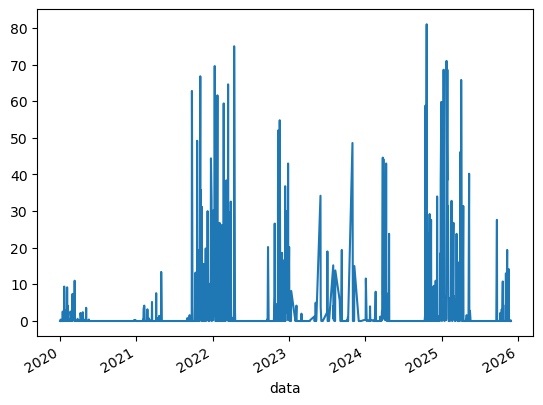

In [59]:
df_normalized['precip_total_mm'].plot()

In [106]:
cols = ['scpdsi_goias',
        'precip_total_mm',
        'TEMPERATURA',
        'ipca',
        'selic',
        'PIB',
        'PIB_Agro',
        'cme_valor',
        'cme_Vol.',
        'boi_futuro',
        'boi_futuro_Vol.',
        'soja_real',
        'soja_dolar',
        'soja_futuro',
        'soja_Vol.',
        'milho_futuro',
        'milho_Vol.',
        'milho_real',
        'milho_dolar',
        'taxa',
        'el_nino_encoded']

In [50]:
df_normalized.columns

NameError: name 'df_normalized' is not defined

In [107]:
for col in cols:
    df_normalized[col] = normalization(df_normalized, scaler, col, dic)


{'column': 'scpdsi_goias', 'p-value': np.float64(0.1552), 'stationarity': True, 'Shapiro-Wilk': np.float64(0.0), 'normality': 'NÃO'}
{'column': 'precip_total_mm', 'p-value': np.float64(0.0006), 'stationarity': True, 'Shapiro-Wilk': np.float64(0.0), 'normality': 'NÃO'}
{'column': 'TEMPERATURA', 'p-value': np.float64(0.056), 'stationarity': True, 'Shapiro-Wilk': np.float64(0.0), 'normality': 'NÃO'}
{'column': 'ipca', 'p-value': np.float64(0.7732), 'stationarity': True, 'Shapiro-Wilk': np.float64(0.0), 'normality': 'NÃO'}
{'column': 'selic', 'p-value': np.float64(0.9567), 'stationarity': True, 'Shapiro-Wilk': np.float64(0.0), 'normality': 'NÃO'}
{'column': 'PIB', 'p-value': np.float64(0.1566), 'stationarity': True, 'Shapiro-Wilk': np.float64(0.0), 'normality': 'NÃO'}
{'column': 'PIB_Agro', 'p-value': np.float64(0.0438), 'stationarity': True, 'Shapiro-Wilk': np.float64(0.0), 'normality': 'NÃO'}
{'column': 'cme_valor', 'p-value': np.float64(0.697), 'stationarity': True, 'Shapiro-Wilk': np.f

In [108]:
df_normalized.columns.to_list()

['CovidPeriodFlag',
 'tarifa_base_carne',
 'tarifa_adicional_trump',
 'tarifas_carne_total',
 'Year',
 'Month',
 'DayOfWeek',
 'ano_novo_flag',
 'carnaval_core_flag',
 'carnaval_window_flag',
 'pascoa_flag',
 'pascoa_window_flag',
 'dias_maes_flag',
 'dias_maes_weekend_flag',
 'festas_juninas_flag',
 'santo_antonio_flag',
 'sao_joao_flag',
 'sao_pedro_flag',
 'ferias_midyear_flag',
 'ferias_verao_flag',
 'dias_pais_flag',
 'dias_pais_weekend_flag',
 'independencia_flag',
 'independencia_window_flag',
 'dia_criancas_flag',
 'finados_flag',
 'finados_weekend_flag',
 'natal_flag',
 'natal_window_flag',
 'fim_ano_window_flag',
 'sazonal_carne_weight',
 'scpdsi_goias',
 'precip_total_mm',
 'TEMPERATURA',
 'ipca',
 'selic',
 'PIB',
 'PIB_Agro',
 'cme_valor',
 'cme_Vol.',
 'boi_futuro',
 'boi_futuro_Vol.',
 'boi_real',
 'boi_dolar',
 'soja_real',
 'soja_dolar',
 'soja_futuro',
 'soja_Vol.',
 'milho_futuro',
 'milho_Vol.',
 'milho_real',
 'milho_dolar',
 'taxa',
 'ciclo_MENOR_TX_NASC',
 'ciclo

In [109]:
df_normalized.drop(columns=['tarifa_base_carne','tarifa_adicional_trump','tarifas_carne_total','Year','Month','DayOfWeek'], inplace=True)

In [110]:
df_normalized.columns.to_list()

['CovidPeriodFlag',
 'ano_novo_flag',
 'carnaval_core_flag',
 'carnaval_window_flag',
 'pascoa_flag',
 'pascoa_window_flag',
 'dias_maes_flag',
 'dias_maes_weekend_flag',
 'festas_juninas_flag',
 'santo_antonio_flag',
 'sao_joao_flag',
 'sao_pedro_flag',
 'ferias_midyear_flag',
 'ferias_verao_flag',
 'dias_pais_flag',
 'dias_pais_weekend_flag',
 'independencia_flag',
 'independencia_window_flag',
 'dia_criancas_flag',
 'finados_flag',
 'finados_weekend_flag',
 'natal_flag',
 'natal_window_flag',
 'fim_ano_window_flag',
 'sazonal_carne_weight',
 'scpdsi_goias',
 'precip_total_mm',
 'TEMPERATURA',
 'ipca',
 'selic',
 'PIB',
 'PIB_Agro',
 'cme_valor',
 'cme_Vol.',
 'boi_futuro',
 'boi_futuro_Vol.',
 'boi_real',
 'boi_dolar',
 'soja_real',
 'soja_dolar',
 'soja_futuro',
 'soja_Vol.',
 'milho_futuro',
 'milho_Vol.',
 'milho_real',
 'milho_dolar',
 'taxa',
 'ciclo_MENOR_TX_NASC',
 'ciclo_NASC_COMPLEMENTARES',
 'ciclo_PICO_NASCIMENTOS',
 'aspecto_PLANEJAMENTO',
 'aspecto_SAFRA',
 'el_nino_enc

In [111]:
df_normalized.to_csv("df_normalized.csv")
df_normalized['boi_real'].head()

data
2020-01-02    192.95
2020-01-03    196.70
2020-01-04    196.70
2020-01-05    196.70
2020-01-06    196.40
Name: boi_real, dtype: float64

### Criação de features temporais (lag, rolling means)

In [389]:
df_lag_normalized = pd.read_csv("df_normalized.csv")
df_lag_normalized.set_index('data', inplace=True)
df_lag_normalized.dtypes

CovidPeriodFlag              float64
Year                         float64
Month                        float64
DayOfWeek                    float64
ano_novo_flag                float64
carnaval_core_flag           float64
carnaval_window_flag         float64
pascoa_flag                  float64
pascoa_window_flag           float64
dias_maes_flag               float64
dias_maes_weekend_flag       float64
festas_juninas_flag          float64
santo_antonio_flag           float64
sao_joao_flag                float64
sao_pedro_flag               float64
ferias_midyear_flag          float64
ferias_verao_flag            float64
dias_pais_flag               float64
dias_pais_weekend_flag       float64
independencia_flag           float64
independencia_window_flag    float64
dia_criancas_flag            float64
finados_flag                 float64
finados_weekend_flag         float64
natal_flag                   float64
natal_window_flag            float64
fim_ano_window_flag          float64
s

In [390]:
cols = df_lag_normalized.columns[2:]
cols_list =  cols.tolist()
print(len(cols_list))

54


In [391]:

df_lag_normalized['month_sin'] = np.sin(2 * np.pi * df_normalized['Month']/12)
df_lag_normalized['month_cos'] = np.cos(2 * np.pi * df_normalized['Month']/12)
df_lag_normalized['dow_sin'] = np.sin(2 * np.pi * df_normalized['DayOfWeek']/7)
df_lag_normalized['dow_cos'] = np.cos(2 * np.pi * df_normalized['DayOfWeek']/7)

In [451]:
import pandas as pd
import numpy as np

def add_time_features(
    df: pd.DataFrame,
    target_cols: list[str],
    lag_list=(1, 2, 3),
    roll_windows=(7, 28),
    roll_stats=("mean", "std"),
    ewm_spans=(7, 28),
    add_diffs=False,
    add_pct_change=False,
    min_periods=1
):
    df = df.copy()

    # Lags do targets
    for col in target_cols:
        for k in lag_list:
            df[f"{col}_lag_{k}"] = df[col].shift(k)

    # Rolling (trailing) do target
    for col in target_cols:
        for w in roll_windows:
            # por linhas
            roll = df[col].rolling(window=w, min_periods=min_periods)
            if "mean" in roll_stats:
                df[f"{col}_rollmean_{w}"] = roll.mean().values
            if "std" in roll_stats:
                df[f"{col}_rollstd_{w}"] = roll.std(ddof=0).values
            if "min" in roll_stats:
                df[f"{col}_rollmin_{w}"] = roll.min().values
            if "max" in roll_stats:
                df[f"{col}_rollmax_{w}"] = roll.max().values
            if "median" in roll_stats:
                df[f"{col}_rollmed_{w}"] = roll.median().values
            if "q10" in roll_stats:
                df[f"{col}_rollq10_{w}"] = roll.quantile(0.10).values
            if "q90" in roll_stats:
               df[f"{col}_rollq90_{w}"] = roll.quantile(0.90).values

    # EWM (média móvel exponencial) do target
    for col in target_cols:
        for s in ewm_spans:
            ewm = df[col].ewm(span=s, adjust=False).mean()
            df[f"{col}_ewm_{s}"] = ewm.values

    # Diferenças e variações
     
    if add_diffs:
        for col in target_cols:
            df[f"{col}_diff_1"] = df[col].diff(1)
            df[f"{col}_diff_7"] = df[col].diff(7)
            df[f"{col}_diff_28"] = df[col].diff(28)

    if add_pct_change:
        for col in target_cols:
            df[f"{col}_pctchg_1"] = df[col].pct_change(1)
            df[f"{col}_pctchg_7"] = df[col].pct_change(7)
            df[f"{col}_pctchg_28"] = df[col].pct_change(28)

    # Lags/rollings também para preditores exógenos (ex.: preco, promo)
    # Exemplo: lag de 'CovidPeriodFlag'
    for k in (1, 7):
        df[f"CovidPeriodFlag_lag_{k}"] = df["CovidPeriodFlag"].shift(k)
    roll_p = df["CovidPeriodFlag"].rolling(window=7, min_periods=min_periods)
    df["CovidPeriodFlag_rollmean_7"] = roll_p.mean().values

    return df

In [454]:
lags = (1, 7)
roll_windows = (1, 7, 28)
target_cols=["soja_real", "milho_real", "boi_futuro"]
df_fet_normalized = add_time_features(
    df_lag_normalized,
    target_cols=target_cols,
    lag_list=lags,
    roll_windows=roll_windows,
    roll_stats=("mean","std"),
    ewm_spans=(7, 14, 28),
)

### Tratamento de NaN's quando aplicado Lag, rolling e EWMS

In [455]:
df_fet_normalized.interpolate(method='linear', limit_direction='both', inplace=True)
df_fet_normalized.head()

,CovidPeriodFlag,Year,Month,DayOfWeek,ano_novo_flag,carnaval_core_flag,carnaval_window_flag,pascoa_flag,pascoa_window_flag,dias_maes_flag,...,soja_real_ewm_28,milho_real_ewm_7,milho_real_ewm_14,milho_real_ewm_28,boi_futuro_ewm_7,boi_futuro_ewm_14,boi_futuro_ewm_28,CovidPeriodFlag_lag_1,CovidPeriodFlag_lag_7,CovidPeriodFlag_rollmean_7
data,,,,,,,,,,,,,,,,,,,,,
2020-01-02,0.0,0.0,0.0,0.560306,0.0,0.0,0.0,0.0,0.0,0.0,...,0.018383,0.025941,0.025941,0.025941,0.434187,0.434187,0.434187,0.0,0.0,0.0
2020-01-03,0.0,0.0,0.0,0.714795,0.0,0.0,0.0,0.0,0.0,0.0,...,0.018703,0.027872,0.026971,0.026474,0.431888,0.432961,0.433553,0.0,0.0,0.0
2020-01-04,0.0,0.0,0.0,0.860761,0.0,0.0,0.0,0.0,0.0,0.0,...,0.018915,0.029427,0.027920,0.026999,0.432016,0.432886,0.433473,0.0,0.0,0.0
2020-01-05,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.019026,0.030700,0.028800,0.027518,0.433952,0.433803,0.433907,0.0,0.0,0.0
2020-01-06,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.019043,0.031763,0.029620,0.028031,0.437235,0.435573,0.434816,0.0,0.0,0.0


In [456]:
df_fet_normalized.isna().sum().sum()

np.int64(0)

In [457]:
df_fet_normalized = df_fet_normalized.replace([np.inf, -np.inf], np.nan).dropna()

In [458]:
df_fet_normalized.head()

,CovidPeriodFlag,Year,Month,DayOfWeek,ano_novo_flag,carnaval_core_flag,carnaval_window_flag,pascoa_flag,pascoa_window_flag,dias_maes_flag,...,soja_real_ewm_28,milho_real_ewm_7,milho_real_ewm_14,milho_real_ewm_28,boi_futuro_ewm_7,boi_futuro_ewm_14,boi_futuro_ewm_28,CovidPeriodFlag_lag_1,CovidPeriodFlag_lag_7,CovidPeriodFlag_rollmean_7
data,,,,,,,,,,,,,,,,,,,,,
2020-01-02,0.0,0.0,0.0,0.560306,0.0,0.0,0.0,0.0,0.0,0.0,...,0.018383,0.025941,0.025941,0.025941,0.434187,0.434187,0.434187,0.0,0.0,0.0
2020-01-03,0.0,0.0,0.0,0.714795,0.0,0.0,0.0,0.0,0.0,0.0,...,0.018703,0.027872,0.026971,0.026474,0.431888,0.432961,0.433553,0.0,0.0,0.0
2020-01-04,0.0,0.0,0.0,0.860761,0.0,0.0,0.0,0.0,0.0,0.0,...,0.018915,0.029427,0.027920,0.026999,0.432016,0.432886,0.433473,0.0,0.0,0.0
2020-01-05,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.019026,0.030700,0.028800,0.027518,0.433952,0.433803,0.433907,0.0,0.0,0.0
2020-01-06,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.019043,0.031763,0.029620,0.028031,0.437235,0.435573,0.434816,0.0,0.0,0.0


In [459]:
rows_with_inf = df_fet_normalized[df_fet_normalized.isin([np.inf, -np.inf]).any(axis=1)]
df_fet_normalized[rows_with_inf].sum().sum()

np.float64(0.0)

In [462]:
df_fet_normalized.columns.tolist()

['CovidPeriodFlag',
 'Year',
 'Month',
 'DayOfWeek',
 'ano_novo_flag',
 'carnaval_core_flag',
 'carnaval_window_flag',
 'pascoa_flag',
 'pascoa_window_flag',
 'dias_maes_flag',
 'dias_maes_weekend_flag',
 'festas_juninas_flag',
 'santo_antonio_flag',
 'sao_joao_flag',
 'sao_pedro_flag',
 'ferias_midyear_flag',
 'ferias_verao_flag',
 'dias_pais_flag',
 'dias_pais_weekend_flag',
 'independencia_flag',
 'independencia_window_flag',
 'dia_criancas_flag',
 'finados_flag',
 'finados_weekend_flag',
 'natal_flag',
 'natal_window_flag',
 'fim_ano_window_flag',
 'sazonal_carne_weight',
 'scpdsi_goias',
 'precip_total_mm',
 'TEMPERATURA',
 'ipca',
 'selic',
 'PIB',
 'PIB_Agro',
 'cme_valor',
 'cme_Vol.',
 'boi_futuro',
 'boi_futuro_Vol.',
 'boi_real',
 'boi_dolar',
 'soja_real',
 'soja_dolar',
 'soja_futuro',
 'soja_Vol.',
 'milho_futuro',
 'milho_Vol.',
 'milho_real',
 'milho_dolar',
 'taxa',
 'ciclo_MENOR_TX_NASC',
 'ciclo_NASC_COMPLEMENTARES',
 'ciclo_PICO_NASCIMENTOS',
 'aspecto_PLANEJAMENTO'

In [463]:
target_cols = ['soja_real_lag_1',
 'soja_real_lag_7',
 'milho_real_lag_1',
 'milho_real_lag_7',
 'boi_futuro_lag_1',
 'boi_futuro_lag_7',
 'soja_real_rollmean_1',
 'soja_real_rollstd_1',
 'soja_real_rollmean_7',
 'soja_real_rollstd_7',
 'soja_real_rollmean_28',
 'soja_real_rollstd_28',
 'milho_real_rollmean_1',
 'milho_real_rollstd_1',
 'milho_real_rollmean_7',
 'milho_real_rollstd_7',
 'milho_real_rollmean_28',
 'milho_real_rollstd_28',
 'boi_futuro_rollmean_1',
 'boi_futuro_rollstd_1',
 'boi_futuro_rollmean_7',
 'boi_futuro_rollstd_7',
 'boi_futuro_rollmean_28',
 'boi_futuro_rollstd_28',
 'soja_real_ewm_7',
 'soja_real_ewm_14',
 'soja_real_ewm_28',
 'milho_real_ewm_7',
 'milho_real_ewm_14',
 'milho_real_ewm_28',
 'boi_futuro_ewm_7',
 'boi_futuro_ewm_14',
 'boi_futuro_ewm_28',
 'CovidPeriodFlag_lag_1',
 'CovidPeriodFlag_lag_7',
 'CovidPeriodFlag_rollmean_7']

In [464]:
df_fet_lag_normalized = df_fet_normalized.copy()
df_fet_lag_normalized.drop(columns='boi_real', inplace=True)
scaler = MinMaxScaler()
dic = {}
for col in target_cols:
    normalization(df_fet_lag_normalized, scaler, col, dic)  

{'column': 'soja_real_lag_1', 'p-value': np.float64(0.3153), 'stationarity': False}
{'column': 'soja_real_lag_7', 'p-value': np.float64(0.3086), 'stationarity': False}
{'column': 'milho_real_lag_1', 'p-value': np.float64(0.2546), 'stationarity': False}
{'column': 'milho_real_lag_7', 'p-value': np.float64(0.271), 'stationarity': False}
{'column': 'boi_futuro_lag_1', 'p-value': np.float64(0.9613), 'stationarity': False}
{'column': 'boi_futuro_lag_7', 'p-value': np.float64(0.9614), 'stationarity': False}
{'column': 'soja_real_rollmean_1', 'p-value': np.float64(0.3124), 'stationarity': False}
{'column': 'soja_real_rollmean_7', 'p-value': np.float64(0.2516), 'stationarity': False}
{'column': 'soja_real_rollstd_7', 'p-value': np.float64(0.0001), 'stationarity': True, 'Shapiro-Wilk': np.float64(0.0), 'normality': 'NÃO'}
{'column': 'soja_real_rollmean_28', 'p-value': np.float64(0.3058), 'stationarity': False, 'Shapiro-Wilk': np.float64(0.0), 'normality': 'NÃO'}


c:\Users\Ricar\miniconda3\envs\agro_proj_01\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1908: RuntimeWarning: invalid value encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1
c:\Users\Ricar\miniconda3\envs\agro_proj_01\lib\site-packages\pmdarima\arima\_auto_solvers.py:40: RuntimeWarning: invalid value encountered in divide
  max_invroot = max(0, *np.abs(1 / model.maroots()))
c:\Users\Ricar\miniconda3\envs\agro_proj_01\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1908: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1


{'column': 'soja_real_rollstd_28', 'p-value': np.float64(0.0001), 'stationarity': True, 'Shapiro-Wilk': np.float64(0.0), 'normality': 'NÃO'}
{'column': 'milho_real_rollmean_1', 'p-value': np.float64(0.2619), 'stationarity': False, 'Shapiro-Wilk': np.float64(0.0), 'normality': 'NÃO'}
{'column': 'milho_real_rollmean_7', 'p-value': np.float64(0.3292), 'stationarity': False, 'Shapiro-Wilk': np.float64(0.0), 'normality': 'NÃO'}
{'column': 'milho_real_rollstd_7', 'p-value': np.float64(0.0), 'stationarity': True, 'Shapiro-Wilk': np.float64(0.0), 'normality': 'NÃO'}
{'column': 'milho_real_rollmean_28', 'p-value': np.float64(0.389), 'stationarity': False, 'Shapiro-Wilk': np.float64(0.0), 'normality': 'NÃO'}
{'column': 'milho_real_rollstd_28', 'p-value': np.float64(0.0), 'stationarity': True, 'Shapiro-Wilk': np.float64(0.0), 'normality': 'NÃO'}
{'column': 'boi_futuro_rollmean_1', 'p-value': np.float64(0.9608), 'stationarity': False, 'Shapiro-Wilk': np.float64(0.0), 'normality': 'NÃO'}
{'column':

In [465]:
df_fet_lag_normalized['boi_real'] = df_fet_normalized['boi_real']
df_fet_lag_normalized.to_csv('df_fet_lag_normalized.csv')
df_fet_lag_normalized.head()

,CovidPeriodFlag,Year,Month,DayOfWeek,ano_novo_flag,carnaval_core_flag,carnaval_window_flag,pascoa_flag,pascoa_window_flag,dias_maes_flag,...,milho_real_ewm_7,milho_real_ewm_14,milho_real_ewm_28,boi_futuro_ewm_7,boi_futuro_ewm_14,boi_futuro_ewm_28,CovidPeriodFlag_lag_1,CovidPeriodFlag_lag_7,CovidPeriodFlag_rollmean_7,boi_real
data,,,,,,,,,,,,,,,,,,,,,
2020-01-02,0.0,0.0,0.0,0.560306,0.0,0.0,0.0,0.0,0.0,0.0,...,0.025941,0.025941,0.025941,0.434187,0.434187,0.434187,0.0,0.0,0.0,192.95
2020-01-03,0.0,0.0,0.0,0.714795,0.0,0.0,0.0,0.0,0.0,0.0,...,0.027872,0.026971,0.026474,0.431888,0.432961,0.433553,0.0,0.0,0.0,196.70
2020-01-04,0.0,0.0,0.0,0.860761,0.0,0.0,0.0,0.0,0.0,0.0,...,0.029427,0.027920,0.026999,0.432016,0.432886,0.433473,0.0,0.0,0.0,196.60
2020-01-05,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.030700,0.028800,0.027518,0.433952,0.433803,0.433907,0.0,0.0,0.0,196.50
2020-01-06,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.031763,0.029620,0.028031,0.437235,0.435573,0.434816,0.0,0.0,0.0,196.40


### Engenharia de features sazonais

Já realizado com os Lags, rollings.

### Detecção e tratamento de outliers

Já realizado com a transformação e normalização.